single obstacle

In [ ]:
import numpy as np
import do_mpc
from casadi import *

def create_mpc(A, obstacles, dt=0.01):
    # Ensure A is a real-valued numpy array
    A = np.asarray(A, dtype=float)

    model = do_mpc.model.Model('continuous')
    B = np.array([[0.0], [1.0]], dtype=float)

    x1 = model.set_variable(var_type='_x', var_name='x1', shape=(1, 1))
    x2 = model.set_variable(var_type='_x', var_name='x2', shape=(1, 1))
    u  = model.set_variable(var_type='_u', var_name='u',  shape=(1, 1))

    model.set_rhs('x1', A[0, 0]*x1 + A[0, 1]*x2 + B[0, 0]*u)
    model.set_rhs('x2', A[1, 0]*x1 + A[1, 1]*x2 + B[1, 0]*u)
    model.setup()

    mpc = do_mpc.controller.MPC(model)
    mpc.set_param(
        n_horizon=6,
        t_step=dt,
        state_discretization='collocation',
        collocation_type='radau',
        store_full_solution=True,
    )

    # Cost
    mterm = 10*x1**2 + x2**2
    lterm = 10*x1**2 + x2**2 + u**2
    mpc.set_objective(mterm=mterm, lterm=lterm)
    mpc.set_rterm(u=0.0)

    # Bounds
    mpc.bounds['lower', '_x', 'x1'] = -10
    mpc.bounds['upper', '_x', 'x1'] =  10
    mpc.bounds['lower', '_x', 'x2'] = -10
    mpc.bounds['upper', '_x', 'x2'] =  10
    mpc.bounds['lower', '_u', 'u']  = -5
    mpc.bounds['upper', '_u', 'u']  =  5

    # Obstacle constraints
    if obstacles is not None:
        for i, obs in enumerate(obstacles):
            cx, cy = obs["center"]
            r = obs["radius"]
            # keep everything real-valued
            cons = -((x1 - float(cx))**2 + (x2 - float(cy))**2) + float(r)**2
            mpc.set_nl_cons(f"obstacle_{i}", cons, ub=0.0)

    mpc.setup()

    simulator = do_mpc.simulator.Simulator(model)
    simulator.set_param(integration_tool='cvodes', t_step=dt)
    simulator.setup()

    return model, mpc, simulator


def simulate_scenario(A, obstacles, dt=0.01, n_steps=500, start_point=(5, 5)):
    # Start from chosen point (force float)
    x0 = np.array([[float(start_point[0])],
                   [float(start_point[1])]], dtype=float)

    model, mpc, simulator = create_mpc(A, obstacles, dt=dt)
    mpc.x0 = x0
    simulator.x0 = x0
    mpc.set_initial_guess()

    state_hist = [x0.squeeze().copy()]  # shape (2,)
    input_hist = []
    total_cost = 0.0

    for _ in range(n_steps):
        u0 = mpc.make_step(x0)
        x_next = simulator.make_step(u0)

        # Ensure numpy float arrays
        x_next = np.array(x_next, dtype=float).reshape(-1, 1)
        u0     = np.array(u0,     dtype=float).reshape(-1, 1)

        state_hist.append(x_next.squeeze().copy())
        input_hist.append(u0.squeeze().copy())

        x1_val, x2_val = x_next[0, 0], x_next[1, 0]
        u_val = u0[0, 0]
        stage_cost = 10*x1_val**2 + x2_val**2 + u_val**2
        total_cost += stage_cost * dt

        x0 = x_next

    # Terminal cost
    x1_val, x2_val = x0[0, 0], x0[1, 0]
    total_cost += (10*x1_val**2 + x2_val**2) * dt

    states = np.array(state_hist, dtype=float)  # (T+1, 2)
    inputs = np.array(input_hist, dtype=float)  # (T,)

    return states, inputs, total_cost


/Users/apple/opt/anaconda3/envs/safe/lib/python3.10/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/Users/apple/opt/anaconda3/envs/safe/lib/python3.10/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or tr

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      158
Number of nonzeros in inequality constraint Jacobian.:       12
Number of nonzeros in Lagrangian Hessian.............:       20

Total number of variables............................:       62
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       46
                     variables with only upper bounds:        0
Total number of equality constraints.................:       50
Total number of inequality constraints...............:        6
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        6

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.9250000e+03 1.74e-01 2.89e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

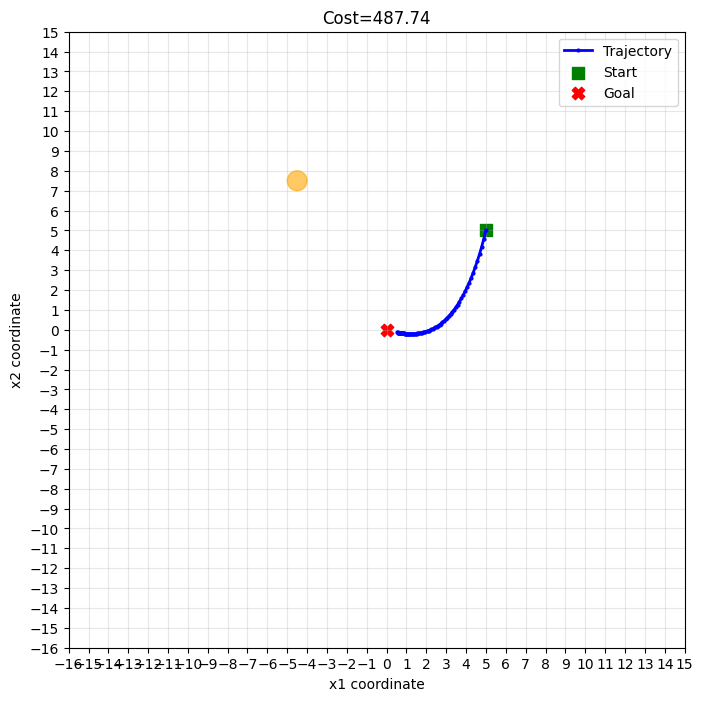

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

dt       = 0.1
n_steps  = 80               # with dt=0.1 and horizon=40, this is 8 seconds
grid_H   = 5
grid_W   = 5
base_cell_radius = 0.5


A = np.array([[-0.28145566,  0.06555046],
 [-0.0453161,  -0.30250244]])




# --------- single obstacle from DB -----------------------------
obstacles = [{'center': (np.float64(-4.5), np.float64(7.5)), 'radius': 0.5}]


goal_point = (0, 0)
start_point  = (grid_H, grid_W)

# --------- run MPC with explicit goal --------------------------
states, inputs, cost = simulate_scenario(
    A=A,
    obstacles=obstacles,
    dt=dt,
    n_steps=n_steps,
    start_point = (5, 5)
)


print(f"Total cost: {cost:.3f}")
print(f"States shape: {states.shape}, Inputs shape: {inputs.shape}")

# --------- plot trajectory + obstacle --------------------------
xs = states[:, 0]
ys = states[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))

# Trajectory
ax.plot(xs, ys, "-o", markersize=2, linewidth=2, color="blue", label="Trajectory")

# Start & Goal
ax.scatter(start_point[0], start_point[1], s=80, c="green", marker="s", label="Start")
ax.scatter(goal_point[0],  goal_point[1],  s=80, c="red",   marker="X", label="Goal")

# Obstacle

row, col = obstacles[0]["center"]
r      = obstacles[0]["radius"]
circle = patches.Circle((row, col), r, color="orange", alpha=0.6)
ax.add_patch(circle)

# Grid & limits
ax.set_aspect("equal")
ax.set_xlim(-3*grid_H, 3*grid_H)
ax.set_ylim(-3*grid_W, 3*grid_W)
ax.set_xticks(range(-3*grid_H-1, 3*grid_H+1)) ###
ax.set_yticks(range(-3*grid_H-1, 3*grid_W+1))
ax.grid(alpha=0.3)

ax.set_xlabel("x1 coordinate")
ax.set_ylabel("x2 coordinate")
ax.set_title(
    f"Cost={cost:.2f}"
)
ax.legend()
plt.show()
